In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving binary.dta to binary.dta


In [7]:
data = pd.read_stata('binary.dta')
print(data.shape)
data.head()

(400, 4)


,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [8]:
data.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [9]:
feature_cols = ['gre', 'gpa', 'rank']
x = data[feature_cols]
y = data['admit']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)
display(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(320, 3)

(320,)

(80, 3)

(80,)

In [11]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [12]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix : ', conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score*100), '%')

Confusion Matrix :  [[50  4]
 [23  3]]
Accuracy Score :  0.6625
Accuracy in Percentage :  66 %


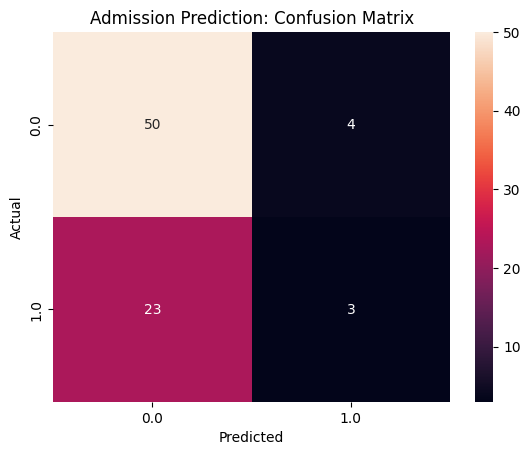

In [13]:
conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True, fmt='d')
plt.title('Admission Prediction: Confusion Matrix')
plt.show()